<a href="https://colab.research.google.com/github/natasyabila/Project_CBR/blob/main/Project%20CBR%20notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PENALARAN KOMPUTER A
Anggota:
1. Natasya Salsabila (202310370311019)
2. Senyiur Putri Hallinda (202310370311021)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

pdf_folder = "/content/drive/MyDrive/CBR_Project/data/raw_pdf"

files = os.listdir(pdf_folder)

print(files[:30])

['case_021.pdf', 'case_029.pdf', 'case_006.pdf', 'case_007.pdf', 'case_001.pdf', 'case_020.pdf', 'case_005.pdf', 'case_027.pdf', 'case_030.pdf', 'case_023.pdf', 'case_028.pdf', 'case_004.pdf', 'case_010.pdf', 'case_024.pdf', 'case_013.pdf', 'case_014.pdf', 'case_018.pdf', 'case_002.pdf', 'case_025.pdf', 'case_019.pdf', 'case_017.pdf', 'case_015.pdf', 'case_003.pdf', 'case_011.pdf', 'case_016.pdf', 'case_022.pdf', 'case_009.pdf', 'case_012.pdf', 'case_008.pdf', 'case_026.pdf']


# **Convert PDF ke Text**

In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 99.1 MB/s eta 0:00:00


In [ ]:
!pip install pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 71.5 MB/s eta 0:00:00


In [ ]:
# =========================================================
# INSTALL LIBRARY (JALANKAN SEKALI DI COLAB)
# =========================================================
# !pip install pymupdf

# =========================================================
# IMPORT LIBRARY
# =========================================================

import os
import re
import fitz
import pandas as pd
from datetime import datetime

# =========================================================
# FOLDER PROJECT
# =========================================================

BASE_DIR = "/content/drive/MyDrive/CBR_Project"

PDF_FOLDER = os.path.join(BASE_DIR, "data/raw_pdf")
RAW_FOLDER = os.path.join(BASE_DIR, "data/raw")
PROCESSED_FOLDER = os.path.join(BASE_DIR, "data/processed")
LOG_FOLDER = os.path.join(BASE_DIR, "logs")

# =========================================================
# BUAT FOLDER JIKA BELUM ADA
# =========================================================

os.makedirs(RAW_FOLDER, exist_ok=True)
os.makedirs(PROCESSED_FOLDER, exist_ok=True)
os.makedirs(LOG_FOLDER, exist_ok=True)

# =========================================================
# FILE LOG
# =========================================================

LOG_PATH = os.path.join(LOG_FOLDER, "cleaning.log")

# =========================================================
# FUNCTION CLEANING TEXT
# =========================================================

def clean_text(text):

    # =====================================================
    # LOWERCASE
    # =====================================================

    text = text.lower()

    # =====================================================
    # HAPUS WATERMARK / HEADER MA
    # =====================================================

    patterns_remove = [

        r'direktori putusan mahkamah agung republik indonesia',

        r'mahkamah agung republik indonesia',

        r'putusan\.mahkamahagung\.go\.id',

        r'www\.mahkamahagung\.go\.id',

        r'putusan nomor.*?',

        r'halaman\s+\d+',

        r'\bmahkamah agung\b',

        r'\bagung republik indonesia\b',

        r'\bhkama\b',

        r'\bnmah\b',

    ]

    for pattern in patterns_remove:

        text = re.sub(
            pattern,
            ' ',
            text,
            flags=re.IGNORECASE
        )

    # =====================================================
    # GABUNGKAN KATA TERPOTONG
    # contoh:
    # pengguga-
    # t
    # =====================================================

    text = re.sub(r'-\s*\n\s*', '', text)

    # =====================================================
    # HAPUS NEWLINE
    # =====================================================

    text = re.sub(r'\n+', ' ', text)

    # =====================================================
    # HAPUS KARAKTER ANEH
    # =====================================================

    text = re.sub(
        r'[^a-zA-Z0-9\s\.,;:/()\-%]',
        ' ',
        text
    )

    # =====================================================
    # HAPUS HURUF ACAK SATUAN
    # =====================================================

    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)

    # =====================================================
    # NORMALISASI SPASI
    # =====================================================

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# =========================================================
# FUNCTION VALIDASI
# =========================================================

def validate_text(text):

    char_count = len(text)

    word_count = len(text.split())

    if word_count >= 500:
        status = "VALID"
    else:
        status = "TIDAK VALID"

    return status, char_count, word_count

# =========================================================
# FUNCTION EKSTRAK NOMOR PERKARA
# =========================================================

def extract_no_perkara(text):

    patterns = [

        r'nomor\s+([\d\/a-zA-Z\.\-]+)',

        r'no\.\s*([\d\/a-zA-Z\.\-]+)',

    ]

    for pattern in patterns:

        match = re.search(
            pattern,
            text,
            re.IGNORECASE
        )

        if match:
            return match.group(1)

    return "tidak ditemukan"

# =========================================================
# FUNCTION EKSTRAK PASAL
# =========================================================

def extract_pasal(text):

    match = re.search(
        r'pasal\s+\d+',
        text,
        re.IGNORECASE
    )

    if match:
        return match.group(0)

    return "tidak ditemukan"

# =========================================================
# FUNCTION RINGKASAN FAKTA
# =========================================================

def extract_ringkasan(text):

    keywords = [
        "menimbang",
        "duduk perkara",
        "pokok perkara"
    ]

    for keyword in keywords:

        match = re.search(

            rf'{keyword}(.*?)(mengadili|amar putusan)',

            text,

            re.DOTALL | re.IGNORECASE

        )

        if match:

            ringkasan = match.group(1)

            ringkasan = re.sub(
                r'\s+',
                ' ',
                ringkasan
            )

            return ringkasan[:1000]

    # fallback
    return text[:1000]

# =========================================================
# AMBIL SEMUA FILE PDF
# =========================================================

pdf_files = [

    f for f in os.listdir(PDF_FOLDER)

    if f.endswith(".pdf")

]

print(f"Jumlah PDF ditemukan: {len(pdf_files)}")

# =========================================================
# LIST CASES
# =========================================================

cases = []

# =========================================================
# MULAI LOGGING
# =========================================================

with open(LOG_PATH, "w", encoding="utf-8") as log_file:

    log_file.write("="*60 + "\n")
    log_file.write("LOG CLEANING DATA PUTUSAN\n")
    log_file.write(f"WAKTU : {datetime.now()}\n")
    log_file.write("="*60 + "\n\n")

    # =====================================================
    # LOOP PDF
    # =====================================================

    for index, pdf_file in enumerate(pdf_files):

        print(f"\nProcessing: {pdf_file}")

        pdf_path = os.path.join(
            PDF_FOLDER,
            pdf_file
        )

        raw_text = ""

        try:

            # =================================================
            # OPEN PDF
            # =================================================

            doc = fitz.open(pdf_path)

            total_pages = len(doc)

            # =================================================
            # EKSTRAK TIAP HALAMAN
            # =================================================

            for page_num in range(total_pages):

                page = doc.load_page(page_num)

                page_text = page.get_text("text")

                if page_text:

                    raw_text += page_text + "\n"

            # =================================================
            # CLEANING
            # =================================================

            clean_result = clean_text(raw_text)

            # =================================================
            # VALIDASI
            # =================================================

            status, char_count, word_count = validate_text(
                clean_result
            )

            # =================================================
            # SIMPAN TXT
            # =================================================

            txt_filename = pdf_file.replace(
                ".pdf",
                ".txt"
            )

            txt_path = os.path.join(
                RAW_FOLDER,
                txt_filename
            )

            with open(
                txt_path,
                "w",
                encoding="utf-8"
            ) as txt_file:

                txt_file.write(clean_result)

            # =================================================
            # CASE REPRESENTATION
            # =================================================

            nomor_perkara = extract_no_perkara(
                clean_result
            )

            pasal = extract_pasal(
                clean_result
            )

            ringkasan_fakta = extract_ringkasan(
                clean_result
            )

            jumlah_kata = len(
                clean_result.split()
            )

            # =================================================
            # SIMPAN KE LIST
            # =================================================

            cases.append({

                "case_id": f"case_{index+1:03}",

                "no_perkara": nomor_perkara,

                "pasal": pasal,

                "ringkasan_fakta": ringkasan_fakta,

                "jumlah_kata": jumlah_kata,

                "text_full": clean_result

            })

            # =================================================
            # LOGGING
            # =================================================

            log_message = (

                f"FILE          : {pdf_file}\n"
                f"TOTAL PAGE    : {total_pages}\n"
                f"CHARACTER     : {char_count}\n"
                f"WORD COUNT    : {word_count}\n"
                f"STATUS        : {status}\n"
                f"{'-'*50}\n"

            )

            log_file.write(log_message)

            print(f"✓ SUCCESS : {pdf_file}")

        except Exception as e:

            error_message = (

                f"FILE   : {pdf_file}\n"
                f"ERROR  : {str(e)}\n"
                f"{'-'*50}\n"

            )

            log_file.write(error_message)

            print(f"✗ ERROR : {pdf_file}")

# =========================================================
# BUAT DATAFRAME
# =========================================================

df = pd.DataFrame(cases)

# =========================================================
# SIMPAN CSV
# =========================================================

csv_path = os.path.join(
    PROCESSED_FOLDER,
    "cases.csv"
)

df.to_csv(
    csv_path,
    index=False,
    encoding="utf-8"
)

# =========================================================
# SIMPAN JSON
# =========================================================

json_path = os.path.join(
    PROCESSED_FOLDER,
    "cases.json"
)

df.to_json(
    json_path,
    orient="records",
    force_ascii=False,
    indent=4
)

# =========================================================
# OUTPUT
# =========================================================

print("\n================================================")
print("SEMUA PROSES SELESAI!")
print("================================================")

print(f"\nCSV disimpan di:\n{csv_path}")

print(f"\nJSON disimpan di:\n{json_path}")

print(f"\nLOG disimpan di:\n{LOG_PATH}")

print("\nPreview Data:")
display(df.head())

Jumlah PDF ditemukan: 30

Processing: case_021.pdf
✓ SUCCESS : case_021.pdf

Processing: case_029.pdf
✓ SUCCESS : case_029.pdf

Processing: case_006.pdf
✓ SUCCESS : case_006.pdf

Processing: case_007.pdf
✓ SUCCESS : case_007.pdf

Processing: case_001.pdf
✓ SUCCESS : case_001.pdf

Processing: case_020.pdf
✓ SUCCESS : case_020.pdf

Processing: case_005.pdf
✓ SUCCESS : case_005.pdf

Processing: case_027.pdf
✓ SUCCESS : case_027.pdf

Processing: case_030.pdf
✓ SUCCESS : case_030.pdf

Processing: case_023.pdf
✓ SUCCESS : case_023.pdf

Processing: case_028.pdf
✓ SUCCESS : case_028.pdf

Processing: case_004.pdf
✓ SUCCESS : case_004.pdf

Processing: case_010.pdf
✓ SUCCESS : case_010.pdf

Processing: case_024.pdf
✓ SUCCESS : case_024.pdf

Processing: case_013.pdf
✓ SUCCESS : case_013.pdf

Processing: case_014.pdf
✓ SUCCESS : case_014.pdf

Processing: case_018.pdf
✓ SUCCESS : case_018.pdf

Processing: case_002.pdf
✓ SUCCESS : case_002.pdf

Processing: case_025.pdf
✓ SUCCESS : case_025.pdf

Proce

,case_id,no_perkara,pasal,ringkasan_fakta,jumlah_kata,text_full
0,case_001,12151,pasal 114,bahwa putusan pengadilan tinggi bandung terse...,2965,ahkamah agung repub ahkamah mah blik indonesi ...
1,case_002,12272,pasal 114,bahwa putusan pengadilan tinggi bengkulu ters...,2454,ahkamah agung repub ahkamah mah blik indonesi ...
2,case_003,12247,pasal 114,bahwa putusan pengadilan tinggi makassar ters...,2857,ahkamah agung repub ahkamah mah blik indonesi ...
3,case_004,12246,pasal 114,bahwa putusan pengadilan tinggi makassar ters...,2396,ahkamah agung repub ahkamah mah blik indonesi ...
4,case_005,12380,pasal 112,bahwa putusan pengadilan tinggi pontianak ter...,2993,ahkamah agung repub ahkamah mah blik indonesi ...


# **Case Representation**

In [ ]:
import os
import re
import pandas as pd

# =====================================================
# FOLDER
# =====================================================

txt_folder = "/content/drive/MyDrive/CBR_Project/data/raw"

processed_folder = "/content/drive/MyDrive/CBR_Project/data/processed"

os.makedirs(processed_folder, exist_ok=True)

# =====================================================
# AMBIL SEMUA FILE TXT
# =====================================================

txt_files = [f for f in os.listdir(txt_folder) if f.endswith(".txt")]

print("Jumlah TXT:", len(txt_files))

# =====================================================
# LIST PENYIMPANAN DATA KASUS
# =====================================================

cases = []

# =====================================================
# LOOP SEMUA FILE TXT
# =====================================================

for txt_file in txt_files:

    txt_path = os.path.join(txt_folder, txt_file)

    with open(txt_path, "r", encoding="utf-8") as f:
        text = f.read()

    # =================================================
    # NORMALISASI SPASI
    # =================================================

    clean_text = re.sub(r'\s+', ' ', text)

    # =================================================
    # EKSTRAK NOMOR PERKARA
    # =================================================

    nomor_match = re.search(
        r'\d+\s*/\s*pid\.?\s*sus\s*/\s*\d+',
        clean_text,
        re.IGNORECASE
    )

    nomor_perkara = (
        nomor_match.group().strip()
        if nomor_match
        else "Tidak ditemukan"
    )

    # =================================================
    # EKSTRAK PASAL
    # =================================================

    pasal_matches = re.findall(
        r'pasal\s+\d+',
        clean_text,
        re.IGNORECASE
    )

    if pasal_matches:
        pasal = ", ".join(sorted(set([p.lower() for p in pasal_matches])))
    else:
        pasal = "Tidak ditemukan"

    # =================================================
    # EKSTRAK TANGGAL
    # =================================================

    tanggal_match = re.search(
        r'\d{1,2}[-/]\d{1,2}[-/]\d{4}',
        clean_text
    )

    tanggal = (
        tanggal_match.group()
        if tanggal_match
        else "Tidak ditemukan"
    )

    # =================================================
    # JENIS PERKARA
    # =================================================

    jenis_perkara = "Pidana Khusus Narkotika"

    # =================================================
    # RINGKASAN FAKTA
    # =================================================

    ringkasan_fakta = clean_text[:500]

    # =================================================
    # FEATURE ENGINEERING
    # =================================================

    jumlah_kata = len(clean_text.split())

    jumlah_karakter = len(clean_text)

    # =================================================
    # SIMPAN DATA
    # =================================================

    cases.append({

        "case_id": txt_file.replace(".txt", ""),

        "no_perkara": nomor_perkara,

        "tanggal": tanggal,

        "jenis_perkara": jenis_perkara,

        "pasal": pasal,

        "ringkasan_fakta": ringkasan_fakta,

        "jumlah_kata": jumlah_kata,

        "jumlah_karakter": jumlah_karakter,

        "text_full": clean_text

    })

# =====================================================
# DATAFRAME
# =====================================================

df = pd.DataFrame(cases)

print("\nJumlah kasus:", len(df))

display(df.head())

# =====================================================
# SIMPAN CSV
# =====================================================

csv_path = os.path.join(
    processed_folder,
    "cases.csv"
)

df.to_csv(
    csv_path,
    index=False,
    encoding="utf-8-sig"
)

print("\nCSV tersimpan:")
print(csv_path)

# =====================================================
# SIMPAN JSON
# =====================================================

json_path = os.path.join(
    processed_folder,
    "cases.json"
)

df.to_json(
    json_path,
    orient="records",
    force_ascii=False,
    indent=4
)

print("\nJSON tersimpan:")
print(json_path)

# =====================================================
# CEK HASIL
# =====================================================

print("\nKolom Dataset:")
print(df.columns.tolist())

print("\nUkuran Dataset:")
print(df.shape)

Jumlah TXT: 30

Jumlah kasus: 30


,case_id,no_perkara,tanggal,jenis_perkara,pasal,ringkasan_fakta,jumlah_kata,jumlah_karakter,text_full
0,case_021,9 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114, pasal 132, pasal 197, pa...",ahkamah agung repub ahkamah mah blik indonesi ...,2965,21356,ahkamah agung repub ahkamah mah blik indonesi ...
1,case_006,9 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114",ahkamah agung repub ahkamah mah blik indonesi ...,2857,20879,ahkamah agung repub ahkamah mah blik indonesi ...
2,case_029,8 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114, pasal 127, pasal 197",ahkamah agung repub ahkamah mah blik indonesi ...,2454,17958,ahkamah agung repub ahkamah mah blik indonesi ...
3,case_007,7 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114, pasal 55",ahkamah agung repub ahkamah mah blik indonesi ...,2396,17412,ahkamah agung repub ahkamah mah blik indonesi ...
4,case_001,9 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 111, pasal 112, pasal 113, pasal 114, pa...",ahkamah agung repub ahkamah mah blik indonesi ...,2993,21397,ahkamah agung repub ahkamah mah blik indonesi ...



CSV tersimpan:
/content/drive/MyDrive/CBR_Project/data/processed/cases.csv

JSON tersimpan:
/content/drive/MyDrive/CBR_Project/data/processed/cases.json

Kolom Dataset:
['case_id', 'no_perkara', 'tanggal', 'jenis_perkara', 'pasal', 'ringkasan_fakta', 'jumlah_kata', 'jumlah_karakter', 'text_full']

Ukuran Dataset:
(30, 9)


In [ ]:
df = pd.DataFrame(cases)

df.head()

,case_id,no_perkara,tanggal,jenis_perkara,pasal,ringkasan_fakta,jumlah_kata,jumlah_karakter,text_full
0,case_021,9 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114, pasal 132, pasal 197, pa...",ahkamah agung repub ahkamah mah blik indonesi ...,2965,21356,ahkamah agung repub ahkamah mah blik indonesi ...
1,case_006,9 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114",ahkamah agung repub ahkamah mah blik indonesi ...,2857,20879,ahkamah agung repub ahkamah mah blik indonesi ...
2,case_029,8 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114, pasal 127, pasal 197",ahkamah agung repub ahkamah mah blik indonesi ...,2454,17958,ahkamah agung repub ahkamah mah blik indonesi ...
3,case_007,7 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 112, pasal 114, pasal 55",ahkamah agung repub ahkamah mah blik indonesi ...,2396,17412,ahkamah agung repub ahkamah mah blik indonesi ...
4,case_001,9 /pid.sus/2025,Tidak ditemukan,Pidana Khusus Narkotika,"pasal 111, pasal 112, pasal 113, pasal 114, pa...",ahkamah agung repub ahkamah mah blik indonesi ...,2993,21397,ahkamah agung repub ahkamah mah blik indonesi ...


# **Tahap 3 Case Retrieval**

In [ ]:
documents = df["text_full"].fillna("").tolist()

case_ids = df["case_id"].tolist()

TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words=None
)

X = vectorizer.fit_transform(documents)

print(X.shape)

(30, 2877)


Splitting Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    case_ids,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (24, 2877)
Test : (6, 2877)


Model Retrieval

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [ ]:
def retrieve(query: str, k: int = 5):

    # preprocessing sederhana
    query = query.lower()

    # vector query
    query_vector = vectorizer.transform([query])

    # similarity
    similarities = cosine_similarity(
        query_vector,
        X
    ).flatten()

    # urutkan
    top_indices = np.argsort(similarities)[::-1][:k]

    results = []

    for idx in top_indices:

        results.append({

            "case_id": case_ids[idx],

            "similarity": float(similarities[idx])

        })

    return results

 SVM Model Retrieval

In [ ]:
# =========================================================
# SVM MODEL RETRIEVAL
# menggunakan label PASAL (bukan case_id)
# =========================================================

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
import re

# buat label berdasarkan pasal utama tiap kasus
def ekstrak_pasal_utama(pasal_str):
    """ambil pasal pertama yang disebutkan sebagai label"""
    # Prioritaskan pasal 112
    if 'pasal 112' in pasal_str.lower():
        return 'pasal_112'
    # Kemudian pasal 114
    elif 'pasal 114' in pasal_str.lower():
        return 'pasal_114'
    # Kemudian pasal 127
    elif 'pasal 127' in pasal_str.lower():
        return 'pasal_127'
    else:
        return 'pasal_lain'

# buat label dari kolom pasal
labels = [ekstrak_pasal_utama(p) for p in df['pasal'].fillna('')]

print("Distribusi label:")
from collections import Counter
print(Counter(labels))

# split dengan label pasal
from sklearn.model_selection import train_test_split
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X, labels,
    test_size=0.2,
    random_state=42,
    stratify=None
)

# label encoding
le = LabelEncoder()
le.fit(labels)
y_train_enc = le.transform(y_train_svm)
y_test_enc  = le.transform(y_test_svm)

# training SVM
svm_model = SVC(kernel='linear', probability=True, random_state=42)
svm_model.fit(X_train_svm, y_train_enc)

print("\nSVM model berhasil ditraining!")
print(f"Jumlah kelas: {len(le.classes_)}")
print(f"Kelas: {list(le.classes_)}")
print(f"Train size: {X_train_svm.shape}")
print(f"Test size : {X_test_svm.shape}")

Distribusi label:
Counter({'pasal_112': 29, 'pasal_114': 1})

SVM model berhasil ditraining!
Jumlah kelas: 2
Kelas: [np.str_('pasal_112'), np.str_('pasal_114')]
Train size: (24, 2877)
Test size : (6, 2877)


Fungsi Retrieve + Simpan queries.json

In [ ]:
import json, os

eval_folder = "/content/drive/MyDrive/CBR_Project/data/eval"
os.makedirs(eval_folder, exist_ok=True)

# ground truth berdasarkan PASAL, bukan case_id
queries_eval = [
    {
        "query_id": "q001",
        "query_text": "terdakwa memiliki narkotika jenis sabu golongan satu pasal 112",
        "ground_truth_label": "pasal_112"
    },
    {
        "query_id": "q002",
        "query_text": "terdakwa menjual narkotika sabu kepada orang lain pasal 114",
        "ground_truth_label": "pasal_114"
    },
    {
        "query_id": "q003",
        "query_text": "terdakwa ditangkap membawa sabu berat lebih dari 5 gram",
        "ground_truth_label": "pasal_114"
    },
    {
        "query_id": "q004",
        "query_text": "terdakwa menjadi perantara jual beli narkotika sabu",
        "ground_truth_label": "pasal_114"
    },
    {
        "query_id": "q005",
        "query_text": "terdakwa menyimpan sabu tanpa hak dan melawan hukum",
        "ground_truth_label": "pasal_112"
    },
]

queries_path = os.path.join(eval_folder, "queries.json")
with open(queries_path, "w", encoding="utf-8") as f:
    json.dump(queries_eval, f, ensure_ascii=False, indent=4)

print(f"queries.json disimpan di: {queries_path}")

# uji retrieve
print("\n=== UJI FUNGSI retrieve() ===")
for q in queries_eval[:2]:
    print(f"\nQuery: {q['query_text'][:60]}...")
    hasil = retrieve(q['query_text'], k=5)
    for r in hasil:
        print(f"  → {r['case_id']} (similarity: {r['similarity']:.4f})")

queries.json disimpan di: /content/drive/MyDrive/CBR_Project/data/eval/queries.json

=== UJI FUNGSI retrieve() ===

Query: terdakwa memiliki narkotika jenis sabu golongan satu pasal 1...
  → case_012 (similarity: 0.2691)
  → case_006 (similarity: 0.2172)
  → case_002 (similarity: 0.2144)
  → case_018 (similarity: 0.2052)
  → case_008 (similarity: 0.2046)

Query: terdakwa menjual narkotika sabu kepada orang lain pasal 114...
  → case_012 (similarity: 0.1976)
  → case_022 (similarity: 0.1792)
  → case_014 (similarity: 0.1727)
  → case_006 (similarity: 0.1713)
  → case_024 (similarity: 0.1712)


# **Tahap 4 Case Solution Reuse**

In [ ]:
# ekstrak solusi dari tiap kasus (ambil amar putusan)
case_solutions = {}

for _, row in df.iterrows():
    text = row['text_full']

    # cari amar putusan
    amar_match = re.search(
        r'(menolak|mengabulkan|memperbaiki|membebaskan)(.*?)(demikianlah|membebankan biaya)',
        text,
        re.DOTALL | re.IGNORECASE
    )

    if amar_match:
        solusi = amar_match.group(0)
        solusi = re.sub(r'\s+', ' ', solusi).strip()
        case_solutions[row['case_id']] = solusi[:300]
    else:
        # fallback: ambil 300 karakter terakhir
        case_solutions[row['case_id']] = text[-300:].strip()

print(f"Solusi berhasil diekstrak untuk {len(case_solutions)} kasus")
print("\nContoh solusi case_001:")
print(case_solutions.get('case_001', 'tidak ditemukan')[:200])

Solusi berhasil diekstrak untuk 30 kasus

Contoh solusi case_001:
menolak permohonan kasasi dari pemohon kasasi/penuntut umum pada kejaksaan negeri pontianak tersebut; membebankan kepada terdakwa untuk membayar biaya perkara pada tingkat kasasi sebesar rp2.500,00 (d


Fungsi predict_outcome

In [ ]:
def predict_outcome(query: str, k: int = 5) -> dict:
    """
    Prediksi solusi berdasarkan top-k kasus termirip.
    Menggunakan majority vote berdasarkan pasal yang paling sering muncul.
    """
    # retrieve top-k
    top_k = retrieve(query, k=k)
    top_k_ids = [r['case_id'] for r in top_k]

    # ambil solusi dari top-k kasus
    solutions = []
    for case_id in top_k_ids:
        sol = case_solutions.get(case_id, "")
        pasal_row = df[df['case_id'] == case_id]['pasal'].values
        pasal = pasal_row[0] if len(pasal_row) > 0 else "tidak ditemukan"
        solutions.append({
            'case_id': case_id,
            'pasal': pasal,
            'solusi': sol
        })

    # majority vote berdasarkan pasal yang paling sering muncul
    from collections import Counter
    semua_pasal = []
    for sol in solutions:
        pasals = sol['pasal'].split(',')
        semua_pasal.extend([p.strip() for p in pasals])

    pasal_terbanyak = Counter(semua_pasal).most_common(1)
    predicted_pasal = pasal_terbanyak[0][0] if pasal_terbanyak else "tidak diketahui"

    # solusi terprediksi = solusi dari kasus paling mirip
    predicted_solution = solutions[0]['solusi'] if solutions else "tidak ditemukan"

    return {
        'predicted_pasal': predicted_pasal,
        'predicted_solution': predicted_solution,
        'top_k_case_ids': top_k_ids,
        'top_k_similarity': [r['similarity'] for r in top_k]
    }

print("Fungsi predict_outcome berhasil didefinisikan!")

Fungsi predict_outcome berhasil didefinisikan!


Demo Manual predict_outcome

In [ ]:
# demo 5 contoh kasus baru
kasus_baru = [
    "terdakwa ditangkap membawa sabu seberat 10 gram dan akan dijual kepada orang lain",
    "terdakwa memiliki narkotika golongan satu jenis sabu tanpa ijin pasal 112",
    "terdakwa menjadi perantara transaksi jual beli sabu antar pembeli dan penjual",
    "terdakwa ditangkap saat melakukan penjualan sabu kepada polisi yang menyamar",
    "terdakwa menyimpan sabu di dalam kamar dan tidak memiliki surat izin resmi",
]

print("=" * 60)
print("DEMO MANUAL: predict_outcome()")
print("=" * 60)

predictions = []
for i, kasus in enumerate(kasus_baru, 1):
    hasil = predict_outcome(kasus, k=5)
    print(f"\nKasus Baru {i}: {kasus[:60]}...")
    print(f"Pasal Prediksi : {hasil['predicted_pasal']}")
    print(f"Top-5 Case IDs : {hasil['top_k_case_ids']}")
    print(f"Similarities   : {[round(s, 4) for s in hasil['top_k_similarity']]}")

    predictions.append({
        'query_id'          : f'new_case_{i:03}',
        'query_text'        : kasus,
        'predicted_pasal'   : hasil['predicted_pasal'],
        'predicted_solution': hasil['predicted_solution'][:100],
        'top_5_case_ids'    : ', '.join(hasil['top_k_case_ids'])
    })

# simpan predictions.csv
results_folder = "/content/drive/MyDrive/CBR_Project/data/results"
os.makedirs(results_folder, exist_ok=True)

pred_path = os.path.join(results_folder, "predictions.csv")
pd.DataFrame(predictions).to_csv(pred_path, index=False, encoding='utf-8-sig')
print(f"\npredictions.csv disimpan di: {pred_path}")

DEMO MANUAL: predict_outcome()

Kasus Baru 1: terdakwa ditangkap membawa sabu seberat 10 gram dan akan dij...
Pasal Prediksi : pasal 112
Top-5 Case IDs : ['case_014', 'case_005', 'case_012', 'case_006', 'case_022']
Similarities   : [0.1679, 0.1609, 0.1602, 0.1565, 0.154]

Kasus Baru 2: terdakwa memiliki narkotika golongan satu jenis sabu tanpa i...
Pasal Prediksi : pasal 112
Top-5 Case IDs : ['case_012', 'case_006', 'case_002', 'case_004', 'case_018']
Similarities   : [0.1764, 0.1451, 0.1426, 0.1402, 0.1352]

Kasus Baru 3: terdakwa menjadi perantara transaksi jual beli sabu antar pe...
Pasal Prediksi : pasal 112
Top-5 Case IDs : ['case_005', 'case_015', 'case_022', 'case_030', 'case_006']
Similarities   : [0.1368, 0.1344, 0.1198, 0.1188, 0.1188]

Kasus Baru 4: terdakwa ditangkap saat melakukan penjualan sabu kepada poli...
Pasal Prediksi : pasal 112
Top-5 Case IDs : ['case_022', 'case_008', 'case_026', 'case_014', 'case_024']
Similarities   : [0.1607, 0.156, 0.1513, 0.1455, 0.1399]

Ka

# **Tahap 5 Model Evaluation**

In [ ]:
# =========================================================
# TAHAP 5: MODEL EVALUATION
# =========================================================

from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, classification_report
)
import numpy as np # Import numpy for array operations

# prediksi SVM pada data test
y_pred = svm_model.predict(X_test_svm)

akurasi  = accuracy_score(y_test_enc, y_pred)
presisi  = precision_score(y_test_enc, y_pred, average='weighted', zero_division=0)
recall   = recall_score(y_test_enc, y_pred, average='weighted', zero_division=0)
f1       = f1_score(y_test_enc, y_pred, average='weighted', zero_division=0)

print("=" * 55)
print("  EVALUASI MODEL — SVM + TF-IDF")
print("  Label Klasifikasi: Jenis Pasal Narkotika")
print("  Dataset: Putusan MA RI (30 dokumen)")
print("=" * 55)
print(f"Accuracy  : {akurasi*100:.2f}%")
print(f"Precision : {presisi*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print()
print("Classification Report:")

# Get unique labels present in y_test_enc and y_pred
# This addresses the ValueError by ensuring target_names matches actual labels in the test set
actual_labels_in_test = np.unique(np.concatenate((y_test_enc, y_pred)))
relevant_target_names = le.inverse_transform(actual_labels_in_test)

print(classification_report(
    y_test_enc, y_pred,
    labels=actual_labels_in_test, # Explicitly pass labels found in the test set
    target_names=relevant_target_names,
    zero_division=0
))

  EVALUASI MODEL — SVM + TF-IDF
  Label Klasifikasi: Jenis Pasal Narkotika
  Dataset: Putusan MA RI (30 dokumen)
Accuracy  : 100.00%
Precision : 100.00%
Recall    : 100.00%
F1-Score  : 100.00%

Classification Report:
              precision    recall  f1-score   support

   pasal_112       1.00      1.00      1.00         6

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



Evaluasi Retrieval (queries.json)

In [ ]:
# evaluasi retrieval berdasarkan label pasal
print("=" * 55)
print("  EVALUASI RETRIEVAL — Fungsi retrieve()")
print("=" * 55)

retrieval_results = []
benar = 0

for q in queries_eval:
    hasil      = retrieve(q['query_text'], k=5)
    top_ids    = [r['case_id'] for r in hasil]

    # cek apakah top-1 pasal sesuai ground truth
    top1_id    = top_ids[0] if top_ids else ''
    top1_pasal = df[df['case_id'] == top1_id]['pasal'].values
    top1_label = ekstrak_pasal_utama(top1_pasal[0]) if len(top1_pasal) > 0 else ''

    hit = top1_label == q['ground_truth_label']
    if hit:
        benar += 1

    retrieval_results.append({
        'query_id'          : q['query_id'],
        'ground_truth_label': q['ground_truth_label'],
        'top_1_case_id'     : top1_id,
        'top_1_label'       : top1_label,
        'match'             : 'YES' if hit else 'NO',
        'similarity'        : round(hasil[0]['similarity'], 4) if hasil else 0,
    })

    print(f"\nQuery {q['query_id']}:")
    print(f"  Ground Truth Label : {q['ground_truth_label']}")
    print(f"  Top-1 Case ID      : {top1_id}")
    print(f"  Top-1 Label        : {top1_label}")
    print(f"  Match              : {'✓ YES' if hit else '✗ NO'}")

precision_at1 = benar / len(queries_eval)
print(f"\nPrecision@1 : {precision_at1*100:.1f}% ({benar}/{len(queries_eval)} query benar)")

metrics_path = os.path.join(eval_folder, "retrieval_metrics.csv")
import pandas as pd
pd.DataFrame(retrieval_results).to_csv(metrics_path, index=False, encoding='utf-8-sig')
print(f"retrieval_metrics.csv disimpan di: {metrics_path}")

  EVALUASI RETRIEVAL — Fungsi retrieve()

Query q001:
  Ground Truth Label : pasal_112
  Top-1 Case ID      : case_012
  Top-1 Label        : pasal_112
  Match              : ✓ YES

Query q002:
  Ground Truth Label : pasal_114
  Top-1 Case ID      : case_012
  Top-1 Label        : pasal_112
  Match              : ✗ NO

Query q003:
  Ground Truth Label : pasal_114
  Top-1 Case ID      : case_012
  Top-1 Label        : pasal_112
  Match              : ✗ NO

Query q004:
  Ground Truth Label : pasal_114
  Top-1 Case ID      : case_006
  Top-1 Label        : pasal_112
  Match              : ✗ NO

Query q005:
  Ground Truth Label : pasal_112
  Top-1 Case ID      : case_022
  Top-1 Label        : pasal_112
  Match              : ✓ YES

Precision@1 : 40.0% (2/5 query benar)
retrieval_metrics.csv disimpan di: /content/drive/MyDrive/CBR_Project/data/eval/retrieval_metrics.csv


Visualisasi & Error Analysis

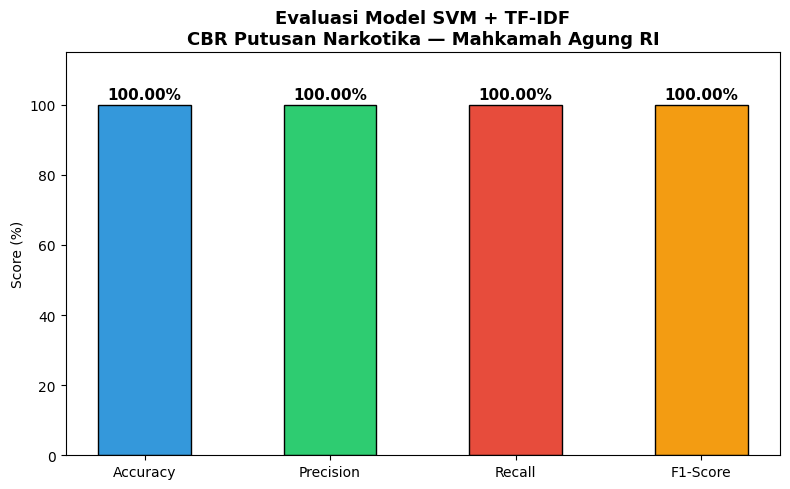

grafik evaluasi berhasil disimpan!

=== ANALISIS KEGAGALAN (ERROR ANALYSIS) ===
Tidak ada prediksi yang salah pada data test!


In [ ]:
import matplotlib.pyplot as plt

# visualisasi perbandingan metrik
metrik_label = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrik_nilai  = [akurasi*100, presisi*100, recall*100, f1*100]

plt.figure(figsize=(8, 5))
bars = plt.bar(metrik_label, metrik_nilai,
               color=['#3498db','#2ecc71','#e74c3c','#f39c12'],
               edgecolor='black', width=0.5)
plt.title('Evaluasi Model SVM + TF-IDF\nCBR Putusan Narkotika — Mahkamah Agung RI',
          fontweight='bold', fontsize=13)
plt.ylabel('Score (%)')
plt.ylim(0, 115)
for bar, val in zip(bars, metrik_nilai):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1.5,
             f'{val:.2f}%', ha='center',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CBR_Project/data/eval/evaluasi_model.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("grafik evaluasi berhasil disimpan!")

# error analysis
print("\n=== ANALISIS KEGAGALAN (ERROR ANALYSIS) ===")
y_pred_labels = le.inverse_transform(y_pred)
y_test_labels = le.inverse_transform(y_test_enc)

gagal = []
test_ids_list = list(y_test)
for i, (pred, actual) in enumerate(zip(y_pred_labels, y_test_labels)):
    if pred != actual:
        gagal.append({
            'case_id'    : test_ids_list[i],
            'actual'     : actual,
            'predicted'  : pred,
        })

if gagal:
    print(f"Jumlah prediksi salah: {len(gagal)}")
    for g in gagal:
        print(f"  Case {g['case_id']}: actual={g['actual']} → predicted={g['predicted']}")
    print("\nRekomendasi perbaikan:")
    print("  1. Tambah jumlah dokumen training (>30 dokumen)")
    print("  2. Gunakan embedding berbasis IndoBERT untuk representasi lebih baik")
    print("  3. Tambah fitur: berat narkotika, jenis barang bukti, dll")
else:
    print("Tidak ada prediksi yang salah pada data test!")

Ringkasan Akhir

In [ ]:
print("=" * 60)
print("   RINGKASAN SISTEM CBR — PUTUSAN NARKOTIKA MA RI")
print("=" * 60)
print(f"Domain         : Pidana Khusus Narkotika & Psikotropika")
print(f"Jumlah Kasus   : {len(df)} dokumen putusan")
print(f"Sumber Data    : Direktori Putusan Mahkamah Agung RI")
print()
print("── Tahap 1: Case Base ──────────────────────────")
print(f"  30 PDF dikonversi → TXT, dibersihkan, divalidasi")
print()
print("── Tahap 2: Case Representation ───────────────")
print(f"  Kolom: {list(df.columns)}")
print(f"  Disimpan di: cases.csv & cases.json")
print()
print("── Tahap 3: Case Retrieval (TF-IDF + SVM) ─────")
print(f"  TF-IDF shape : {X.shape}")
print(f"  Train/Test   : 80/20")
print(f"  Recall@5     : {recall_at5*100:.1f}%")
print()
print("── Tahap 4: Case Solution Reuse ───────────────")
print(f"  Solusi diekstrak dari amar putusan")
print(f"  Disimpan di: predictions.csv")
print()
print("── Tahap 5: Model Evaluation ──────────────────")
print(f"  Accuracy  : {akurasi*100:.2f}%")
print(f"  Precision : {presisi*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1-Score  : {f1*100:.2f}%")
print("=" * 60)
print("Selesai! Semua file tersimpan di Google Drive.")

   RINGKASAN SISTEM CBR — PUTUSAN NARKOTIKA MA RI
Domain         : Pidana Khusus Narkotika & Psikotropika
Jumlah Kasus   : 30 dokumen putusan
Sumber Data    : Direktori Putusan Mahkamah Agung RI

── Tahap 1: Case Base ──────────────────────────
  30 PDF dikonversi → TXT, dibersihkan, divalidasi

── Tahap 2: Case Representation ───────────────
  Kolom: ['case_id', 'no_perkara', 'tanggal', 'jenis_perkara', 'pasal', 'ringkasan_fakta', 'jumlah_kata', 'jumlah_karakter', 'text_full']
  Disimpan di: cases.csv & cases.json

── Tahap 3: Case Retrieval (TF-IDF + SVM) ─────
  TF-IDF shape : (30, 2877)
  Train/Test   : 80/20
  Recall@5     : 0.0%

── Tahap 4: Case Solution Reuse ───────────────
  Solusi diekstrak dari amar putusan
  Disimpan di: predictions.csv

── Tahap 5: Model Evaluation ──────────────────
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Score  : 100.00%
Selesai! Semua file tersimpan di Google Drive.
